In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils
import TCR_embedings

2026-05-20 11:23:13.627872: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-20 11:23:13.628182: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-20 11:23:13.661551: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-20 11:23:15.489399: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

In [2]:
# importlib.reload(mdata_utils)

# Merge the data

In [3]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external/EAE"

/ix1/ylee/Yifan_Zhang/Code_data/external/EAE


In [4]:
from pathlib import Path
import re

# Get all folders that don't start with '_'
current_dir = Path('.')
folders = [f for f in current_dir.iterdir() if f.is_dir() and not f.name.startswith('_')]

# Load yz_processed.h5mu from each folder into named variables
mdata_dict = {}
mdata_list = []

n_top_genes = 1000

type_sets = {"CD4" : ['Cd4', 'Cd4a'],
             "CD8" : ['Cd8a','Cd8b1','Nkg7'],
            "Treg": ['Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra'],
            "Th17" : ['Ccr6', 'Il22', 'Il17', 'Il17a'],
                }
state_sets = {"IFN_stim": ['Isg15', 'Gbp2', 'Ifih1'],
            "Activation": ['Icos', 'Cd69', 'Cd28'],
            "Exhaust": ['Pdcd1', 'Lag3', 'Havcr2'],
            "Mem_Naive": ['Ccr7', 'Sell', 'Cd27'],
             }
all_important_genes = []
for gene_list in type_sets.values():
    all_important_genes.extend(gene_list)
for gene_list in state_sets.values():
    all_important_genes.extend(gene_list)
    
gse_to_cell_type = {
    'GSE156718': 'CD4',
    # 'GSE182747': ,  # Adjust based on actual cell type
    'GSE293883': 'CD4',
    'GSE178085': 'Th17',
    'GSE188320': 'Th17',
    # 'GSE1': 'CD4',  # Adjust based on actual cell type (LEE)
}
    
    

In [6]:
# Initialize separate lists for test and train

for folder in folders:
    h5mu_file = folder / 'yz_processed_allGenes_annotateByScore.h5mu'
    
    if h5mu_file.exists():
        print(f"Loading: {h5mu_file}")
        mdata = mu.read(h5mu_file)
        var_name = re.sub(r'[^\w]', '_', folder.name) + '_mdata'
        mdata = mdata_utils.sync_mdata_obs(mdata)
        
        K_HVG = 1000
        GROUP_KEY = "GSM"
        mdata.mod["gex"].obs[GROUP_KEY] = mdata.obs[GROUP_KEY]
        MIN_CELLS_PER_GROUP = 50

        gex = mdata.mod["gex"]
        if gex.n_vars == 0:
            raise RuntimeError("mdata.mod['gex'] has 0 genes. Reload raw mdata before HVG selection.")
        if GROUP_KEY not in gex.obs.columns:
            raise KeyError(f"{GROUP_KEY!r} not found in mdata.mod['gex'].obs")

        genes_union: set[str] = set()
        skipped: list[tuple[object, str]] = []
        counts = gex.obs[GROUP_KEY].value_counts(dropna=True)

        for gid, n in counts.items():
            if n < MIN_CELLS_PER_GROUP:
                skipped.append((gid, f"only {n} cells (< {MIN_CELLS_PER_GROUP})"))
                continue

            sub = gex[gex.obs[GROUP_KEY] == gid].copy()
            sub = sub[:, sub.var_names.notna()].copy()
            # try:

            sc.pp.highly_variable_genes(
                sub,
                n_top_genes=min(K_HVG, sub.n_vars),
                inplace=True,
                # flavor='seurat_v3',   # use raw count
            )
            # except Exception as exc:  # noqa: BLE001
            #     skipped.append((gid, repr(exc)))
            #     continue

            hv = sub.var["highly_variable"].fillna(False).to_numpy(dtype=bool)
            genes_union.update(sub.var_names[hv].astype(str))

        hvg_union = sorted(genes_union)
        if len(hvg_union) == 0:
            raise RuntimeError("HVG union is empty. Check skipped errors above.")

        mask = np.isin(gex.var_names.astype(str), hvg_union)
        selected = gex.var_names[mask]

        gex.var["hvg_union_COMBAT_ID"] = mask
        gex.uns["hvg_union_COMBAT_ID_k200"] = hvg_union
        gex.uns["hvg_union_COMBAT_ID_meta"] = {
            "group_key": GROUP_KEY,
            "k_per_group": K_HVG,
            "min_cells_per_group": MIN_CELLS_PER_GROUP,
            "flavor": "scanpy_default",
            "layer": "scanpy_default",
            "n_groups": int(len(counts)),
            "n_union_genes": int(len(hvg_union)),
        }

        gex_hvg = gex[:, selected].copy()
        gex_hvg.var["hvg_union_COMBAT_ID"] = True
        gex_hvg.uns["hvg_union_COMBAT_ID_k200"] = hvg_union
        gex_hvg.uns["hvg_union_COMBAT_ID_meta"] = dict(gex.uns["hvg_union_COMBAT_ID_meta"])

        mdata.mod["gex"] = gex_hvg
        mdata.uns["hvg_union_COMBAT_ID_meta"] = dict(gex_hvg.uns["hvg_union_COMBAT_ID_meta"])
            
        # Store in dictionary
        mdata_dict[var_name] = mdata
        globals()[var_name] = mdata  # Create variable in global namespace
        mdata_list.append(mdata)
        
            
    else:
        print(f"Skipping {folder.name}: yz_processed.h5mu not found")


Loading: GSE188320 Th17/yz_processed_allGenes_annotateByScore.h5mu
Loading: GSE182747 CNS young and old/yz_processed_allGenes_annotateByScore.h5mu
Loading: GSE293883 CD4 Tr mem day60/yz_processed_allGenes_annotateByScore.h5mu
Loading: GSE178085 Bcl6KO_R Th17/yz_processed_allGenes_annotateByScore.h5mu
Skipping GSE156718 CD4 iLN: yz_processed.h5mu not found
Loading: GSELEE/yz_processed_allGenes_annotateByScore.h5mu


In [7]:
import mudata as md

merged = mdata_utils.merge_mdatas(mdata_list, mods=["gex","airr"], keep_obs_columns="common", index_unique=None)
merged.update()
merged

MuData object with n_obs × n_vars = 132088 × 4836
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state'
  2 modalities
    airr:	132088 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	132088 x 4836
      obs:	'batch', 'condition', 'sample_id', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'GSM', 'sample', 'date', 'mouse_BC'
      var:	'gene_ids', 'feature_types'

In [8]:
# merged = mu.read('merged_EAE.h5mu')

# subset

In [9]:
# merged = merged[merged.obs['condition'].isin(['EAE'])]
# merged = merged[~merged.obs['cell_type'].isin(['CD8'])]

# merged.obs['condition'] = merged.obs['condition'].astype(str)
# merged = merged[merged.obs['condition'].isin(['EAE'])]
# merged = merged[merged['gex'].obs['cell_type'].isin(['CD4'])]
# merged = merged[merged['gex'].obs['tissue'].isin(['CNS'])]
# merged.update()


In [10]:
# reduce number of vars
# sc.pp.highly_variable_genes(merged['gex'], n_top_genes=4000)
# merged.mod['gex'] = merged['gex'][:, merged['gex'].var['highly_variable']].copy()
# merged = mdata_utils.sync_mdata_obs(merged)
        
GEX_df = merged['gex'].to_df()
# GEX_df

# cluster by GEX

In [11]:
sc.pp.pca(merged["gex"], n_comps=50)

### no batch correction

In [12]:
sc.pp.neighbors(merged["gex"], n_neighbors = 50)
sc.tl.umap(merged["gex"], min_dist=0.5, spread=1.0)
sc.tl.leiden(merged["gex"], resolution = 1, n_iterations=-1, flavor = 'igraph')

In [13]:
merged["gex"].obs['GSE'] = merged.obs['GSE']

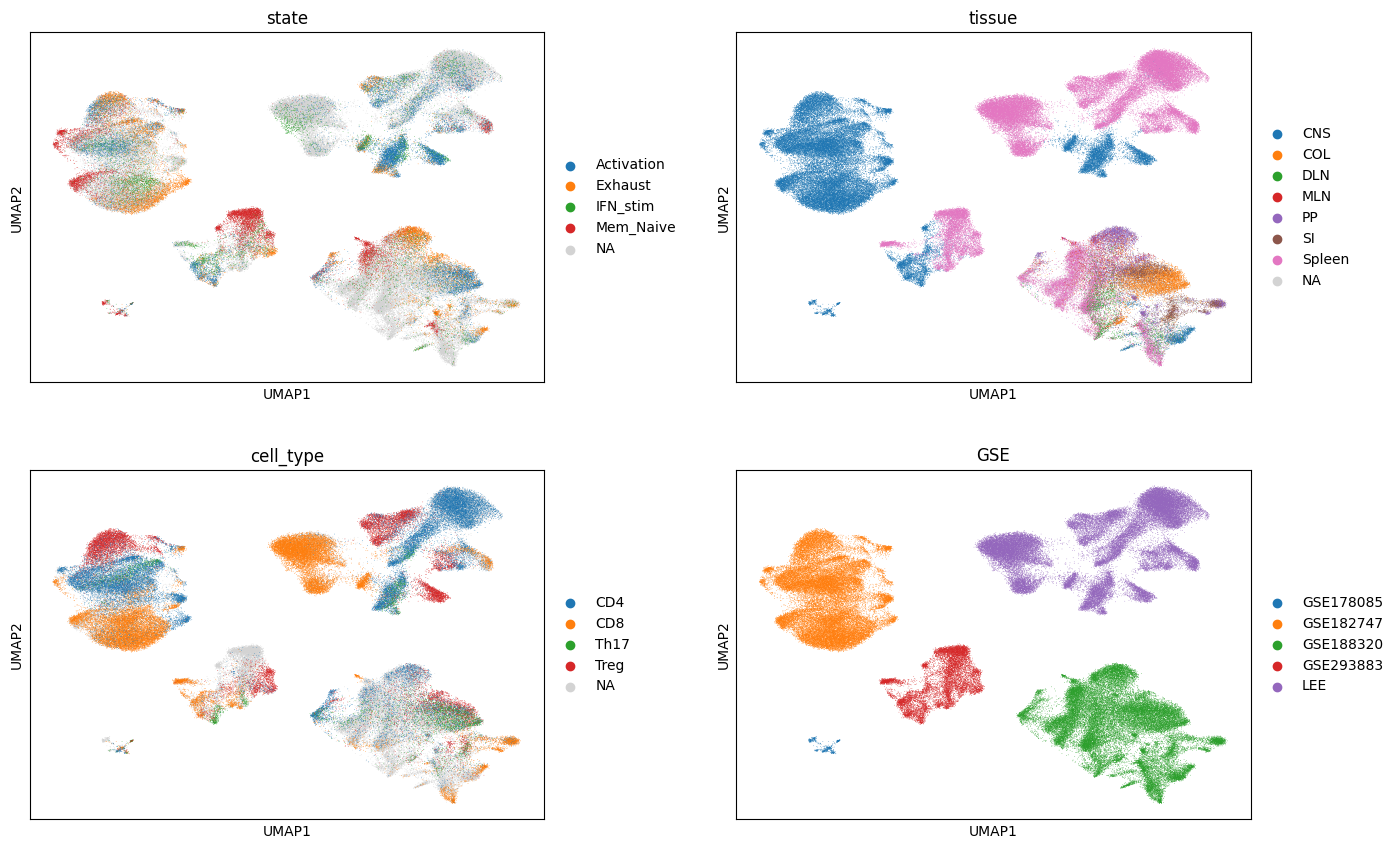

In [14]:
sc.pl.umap(merged["gex"], color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2, wspace=0.25)

In [15]:
merged

MuData object with n_obs × n_vars = 132088 × 4836
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state'
  2 modalities
    airr:	132088 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	132088 x 4836
      obs:	'batch', 'condition', 'sample_id', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'GSM', 'sample', 'date', 'mouse_BC', 'leiden', 'GSE'
      var:	'gene_ids', 'feature_types'
      uns:	'pca', 'neighbors', 'umap', 'leiden', 'state_colors', 'tissue_colors', 'cell_type_colors', 'GSE_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'

### harmony correction

In [16]:
X = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
bad = ~np.isfinite(X).all(axis=1)
if bad.any():
    merged["gex"] = merged["gex"][~bad].copy()
    X = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
merged["gex"].obsm['X_pca'] = np.ascontiguousarray(X)

# merged["gex"].obsm['X_pca'] = np.asarray(merged["gex"].obsm['X_pca'], dtype=np.float64)
# merged["gex"].obs['GSE'] = merged["gex"].obs['GSE'].astype("string").fillna("unknown").astype("category")
merged["gex"].obs['GSE'] = merged["gex"].obs['GSE'].astype("object").astype("category")

In [17]:
merged.obs["GSE"].value_counts()

GSE
LEE          43558
GSE188320    39758
GSE182747    37164
GSE293883    11097
GSE178085      511
Name: count, dtype: Int64

In [18]:
## Batch correction
import scanpy.external as sce
sce.pp.harmony_integrate(merged["gex"], key=["GSE"],  basis='X_pca', max_iter_harmony=30, 
                          theta = 4, lamb = 1.5, sigma=0.1, tau=1)

# https://github.com/slowkow/harmonypy/blob/master/harmonypy/harmony.py
# Integration Control Parameters:
# theta: Diversity clustering penalty parameter. A higher value encourages more diverse clusters.
# lamb: Ridge regression penalty parameter. Controls the strength of the regularization applied during the integration step.
# sigma: Width of soft k-means clusters. Influences the fuzziness of cluster assignments.
# nclust: Number of clusters in the model. If None, Harmony will estimate this number.
# tau: Protection against overclustering small datasets with large ones.

# Convergence and Iteration Parameters:
# max_iter_harmony: Maximum number of iterations for the Harmony algorithm if not converged.
# max_iter_cluster: Maximum number of iterations for the k-means clustering step within each Harmony iteration.
# epsilon_harmony: Convergence threshold for the Harmony objective function.
# epsilon_cluster: Convergence threshold for the k-means clustering objective function.
# plot_convergence: Boolean indicating whether to plot the convergence of the objective function. 
# verbose: Boolean indicating whether to print progress messages during execution.
# Other Parameters:
# block_size: Size of data blocks to process if using a block-wise approach.
# reference_values: Optional dictionary specifying reference values for vars_use.
# return_object: Boolean indicating whether to return the full Harmony model object or just the corrected embeddings.

2026-05-20 11:27:54,085 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-20 11:27:59,701 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-20 11:27:59,885 - harmonypy - INFO - Iteration 1 of 30
2026-05-20 11:28:12,515 - harmonypy - INFO - Iteration 2 of 30
2026-05-20 11:28:25,231 - harmonypy - INFO - Iteration 3 of 30
2026-05-20 11:28:37,836 - harmonypy - INFO - Iteration 4 of 30
2026-05-20 11:28:50,494 - harmonypy - INFO - Iteration 5 of 30
2026-05-20 11:29:03,128 - harmonypy - INFO - Iteration 6 of 30
2026-05-20 11:29:15,781 - harmonypy - INFO - Converged after 6 iterations


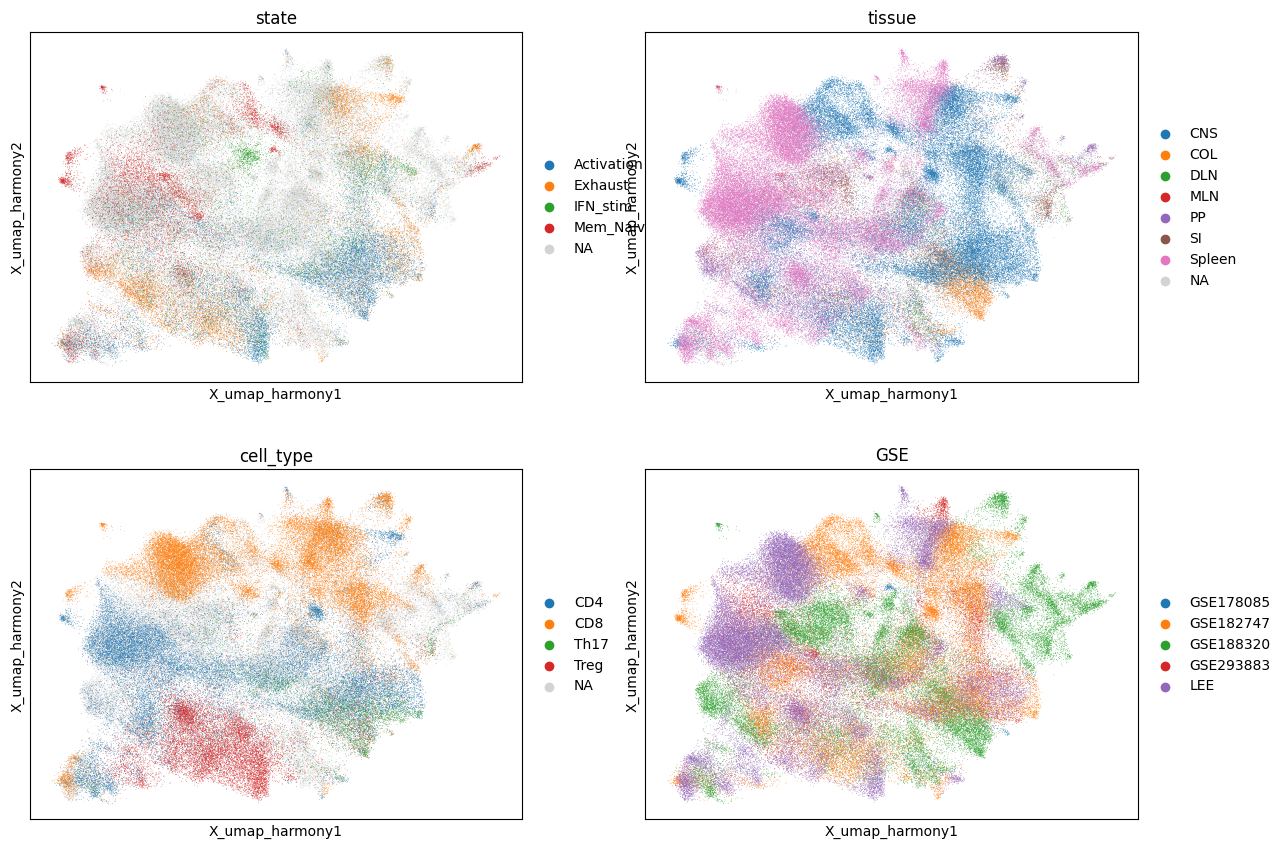

In [19]:
sc.pp.neighbors(merged["gex"], n_neighbors = 30, use_rep='X_pca_harmony', key_added = 'neighbors_harmony')
sc.tl.umap(merged["gex"], min_dist=0.5, spread=1.0, neighbors_key = 'neighbors_harmony', key_added = 'X_umap_harmony')
sc.pl.embedding(merged["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2,)

In [20]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True
merged.write('EAE_HV1000_per_GSM.h5mu')

## ingest all sets to one reference set

In [21]:
# # Use LEE as reference and map the rest using sc.tl.ingest
# # Split into reference (LEE) and query (rest)
# ref_mask = mdata.obs['GSE'] == 'LEE'
# query_mask = ~ref_mask

# print(f"Reference (LEE) cells: {ref_mask.sum()}")
# print(f"Query cells: {query_mask.sum()}")

# # Extract reference and query datasets
# mdata_ref = mdata[ref_mask].copy()
# mdata_query = mdata[query_mask].copy()

# # Prepare reference: ensure PCA is computed
# # Check if PCA exists, if not compute it
# if 'X_pca' not in mdata_ref['gex'].obsm.keys():
#     print("Computing PCA on reference dataset...")
#     sc.pp.highly_variable_genes(mdata_ref['gex'], n_top_genes=2000)
#     sc.pp.scale(mdata_ref['gex'])
#     sc.tl.pca(mdata_ref['gex'], n_comps=50)
# else:
#     print("Using existing PCA from reference dataset")

# # Prepare query: ensure it has the same preprocessing
# # Align genes between reference and query
# common_genes = mdata_ref['gex'].var_names.intersection(mdata_query['gex'].var_names)
# print(f"Common genes between reference and query: {len(common_genes)}")

# # Extract AnnData objects, subset genes, and create new MuData objects
# gex_ref = mdata_ref['gex'][:, common_genes].copy()
# gex_query = mdata_query['gex'][:, common_genes].copy()
# airr_ref = mdata_ref['airr'].copy()
# airr_query = mdata_query['airr'].copy()

# # Recreate MuData objects with subsetted genes
# mdata_ref = mu.MuData({'gex': gex_ref, 'airr': airr_ref})
# mdata_query = mu.MuData({'gex': gex_query, 'airr': airr_query})
# mdata_ref.update()
# mdata_query.update()

# # Ensure query has the same preprocessing steps
# if 'X_pca' not in mdata_query['gex'].obsm.keys():
#     print("Preprocessing query dataset...")
#     # Use the same highly variable genes as reference
#     mdata_query['gex'].var['highly_variable'] = mdata_query['gex'].var_names.isin(
#         mdata_ref['gex'].var_names[mdata_ref['gex'].var['highly_variable']]
#     )
#     sc.pp.scale(mdata_query['gex'])

# # Use sc.tl.ingest to map query to reference
# print("Mapping query to reference using sc.tl.ingest...")
# sc.tl.ingest(
#     mdata_query['gex'], 
#     mdata_ref['gex'], 
#     obs='GSE',
#     embedding_method='pca',
#     neighbors_key=None,
#     inplace=True
# )

# # Combine reference and query back together
# # Concatenate the gex modalities
# gex_combined = mdata_ref['gex'].concatenate(mdata_query['gex'], index_unique=None)

# # For airr modality, we need to maintain the same order
# # Get the combined cell order
# combined_cell_order = gex_combined.obs_names

# # Reorder airr data to match
# airr_ref = mdata_ref['airr']
# airr_query = mdata_query['airr']
# airr_combined = airr_ref.concatenate(airr_query, index_unique=None)

# # Create new combined mdata
# mdata = mu.MuData({'gex': gex_combined, 'airr': airr_combined})
# mdata.update()

# print(f"Combined mdata shape: {mdata.shape}")
# print(f"GSE distribution after ingest:")
# print(mdata.obs['GSE'].value_counts())
